# Iskanje in prenos podatkov izbranega območja 

Delo s celotnimi Planet posnetki je lahko počasno in nerodno, če je vaše območje zanimanja precej manjše od celotnega posnetka. Na srečo lahko uporabite **Cloud Optimized GeoTIFF (COG)** in tako imenovano *okensko branje* (windowed read), da pospešite dostop do podatkov preko Data API. Delo z manjšimi deli Planet posnetkov vam lahko prihrani prostor za shranjevanje in čas.

Upoštevajte, da ta potek dela dostopa do povezave za prenos celotnega posnetka. Dostop do te povezave se obračuna kot prenos **celotne scene**, tudi če dejansko prenesete samo metapodatke ali majhen izrez. Zaradi kvotnega sistema Data API ta pristop ni vedno najbolj stroškovno učinkovit.

Če delate z večjo količino podatkov ali želite optimizirati porabo kvote, razmislite o uporabi **Orders API orodja za izrez (clip)**.

Zato bomo pokazali kako:
* poiskati Planet posnetek z območjem zanimanja (AOI)
* naložiti podatke znotraj meja AOI
* vizualno prikazati piksle znotraj AOI
* uporabiti kontrastno raztezanje za boljši prikaz
* prikazati NDVI znotraj AOI

## Nastavitev okolja

Potrebovali boste **Planet API ključ** in nekaj dodatnih Python knjižnic, kot so `rasterio`, `matplotlib` in `numpy`. Če še nimate API ključa, ga lahko dobite tako, da se prijavite na [Planet Explorer](https://www.planet.com/explorer/) in ustvarite račun.

Če knjižnice še nimate nameščene, jih lahko namestite z uporabo `conda`:

```PowerShell
conda install matplotlib numpy rasterio requests shapely pyproj
```

In [1]:
import getpass
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from pprint import pprint
from pyproj import Transformer
import rasterio
from rasterio.mask import mask
from rasterio.windows import from_bounds
import requests
from shapely.geometry import Polygon, mapping, shape

In [2]:
# Ce vas Planet API kljuc ni nastavljen kot spremenljivka okolja, ga lahko prilepite spodaj
if os.environ.get('PL_API_KEY', ''):
    API_KEY = os.environ.get('PL_API_KEY', '')
else:
    API_KEY = 'PRILEPITE_SVOJ_API_KLJUC_TUKAJ'

In [3]:
# Print API key to verify it was loaded correctly (optional)
print(f'API ključ naložen: {API_KEY[:4]}...{API_KEY[-4:]}')

API ključ naložen: PLAK...d9d4


In [4]:
# Nastavite sejo
session = requests.Session()

# Avtentikacija z API ključem
session.auth = (API_KEY, "")

# Nastavi osnovni URL za podatkovni API
URL = "https://api.planet.com/data/v1"

Preverimo ali je API ključ veljaven z GET zahtevkom za tip podatkov (item type).

In [5]:
# Preverjanje API-ja
test_url = f'{URL}/item-types'
resp = session.get(test_url)
assert resp.ok, f'Nekaj ni v redu: {resp.status_code}, {resp.content}'
print("Vse je pripravljeno, začnimo!")

Vse je pripravljeno, začnimo!


## Iskanje

Najprej bomo uporabili **Data API search endpoint**, da poiščemo posnetek, ki se prekriva z našim območjem zanimanja (AOI).
AOI lahko ustvarite ali narišete z orodjem kot je **geojson.io**.

![GeoJsonIO](slike/geojsonio.png)

In [6]:
# Ime datoteke z AOI
aoi_file = './podatki/kranj_aoi.geojson'
with open(aoi_file) as f:
    geojson_data = json.load(f)
geojson_geometry = geojson_data['features'][0]['geometry']

In [7]:
# Izpis geometrije AOI, da preverite, ali je pravilno prebrana
print(json.dumps(geojson_geometry, indent=2, ensure_ascii=False))

{
  "coordinates": [
    [
      [
        14.338274979185115,
        46.234310509304606
      ],
      [
        14.384337227889091,
        46.234310509304606
      ],
      [
        14.384337227889091,
        46.262948793445105
      ],
      [
        14.338274979185115,
        46.262948793445105
      ],
      [
        14.338274979185115,
        46.234310509304606
      ]
    ]
  ],
  "type": "Polygon"
}


Dodatni **filtri** za dodatno omejitev iskanja v našem API-ju za podatke.

In [8]:
# prekrivanje z AOI 
geometry_filter = {
  "type": "GeometryFilter",
  "field_name": "geometry",
  "config": geojson_geometry
}

# pridobljene v določenem časovnem obdobju
date_range_filter = {
  "type": "DateRangeFilter",
  "field_name": "acquired",
  "config": {
    "gte": "2025-06-01T00:00:00.000Z",
    "lte": "2025-06-30T00:00:00.000Z"
  }
}

# <30 % oblačnost
cloud_cover_filter = {
  "type": "RangeFilter",
  "field_name": "cloud_cover",
  "config": {
    "lte": 0.3
  }
}

# združen filter
combined_filter = {
  "type": "AndFilter",
  "config": [geometry_filter, date_range_filter, cloud_cover_filter]
}

Izvedi iskanje prek http zahtevka

In [9]:
item_type = "PSScene"

# API zahtevek objekt
search_request = {
  "item_types": [item_type], 
  "filter": combined_filter
}

# pošlji zahtevo POST
search_result = \
  session.post(
    'https://api.planet.com/data/v1/quick-search',
    json=search_request)

results = search_result.json()

feat = results['features'][0]
pprint(feat)

{'_links': {'_self': 'https://api.planet.com/data/v1/item-types/PSScene/items/20250629_102455_95_2540',
            'assets': 'https://api.planet.com/data/v1/item-types/PSScene/items/20250629_102455_95_2540/assets/',
            'thumbnail': 'https://tiles.planet.com/data/v1/item-types/PSScene/items/20250629_102455_95_2540/thumb'},
 '_permissions': ['assets.ortho_visual:download',
                  'assets.ortho_analytic_4b:download',
                  'assets.ortho_analytic_4b_xml:download',
                  'assets.basic_analytic_4b:download',
                  'assets.basic_analytic_4b_xml:download',
                  'assets.basic_analytic_4b_rpc:download',
                  'assets.ortho_analytic_4b_sr:download',
                  'assets.ortho_udm2:download',
                  'assets.basic_udm2:download',
                  'assets.ortho_analytic_8b:download',
                  'assets.ortho_analytic_8b_xml:download',
                  'assets.basic_analytic_8b:download',
      

In [10]:
item_geom = feat['geometry']
item_id = feat['id']
asset = 'ortho_analytic_4b'
assert asset in feat['assets']

## Aktivirajte želeno asset

Data API zahteva aktiviranje želenega elementa, preden lahko prenesete ali dostopate do posnetkov.

In [11]:
# Preveri stanje aktivacije
assets_url = f'{URL}/item-types/{item_type}/items/{item_id}/assets'
resp = session.get(assets_url)
asset_info = resp.json().get(asset)
assert asset_info is not None, f"Sredstvo '{asset}' ni na voljo. Na voljo: {list(resp.json().keys())}"
print(f"Stanje sredstva: {asset_info['status']}")

Stanje sredstva: active


Če asset še ni v aktivnem stanju, ga lahko aktivirate s http zahtevkom. Aktiviranje poteka asinhrono in lahko traja nekaj minut. Stanje sredstva lahko redno preverjate.

In [12]:
links = resp.json()[asset]["_links"]
activation_link = links["activate"]

# Request activation of the 'ortho_analytic_4b' asset:
activate_result = session.get(activation_link)

In [13]:
while session.get(assets_url).json()[asset]['status'] != 'active':
    # Preveri stanje aktivacije
    print(f"Stanje asseta: {session.get(assets_url).json()[asset]['status']}")
    time.sleep(30)
print("Asset je aktivno!")

Asset je aktivno!


In [14]:
# ključ lokacije se bo pojavil po zaključku aktivacije
download_link = session.get(assets_url).json()[asset]['location']

Ne pozabite, da bo uporaba te povezave `download_link` **obremenila vašo kvoto za celoten element.**

## Branje podatkov iz AOI
Sedaj, ko je sredstvo aktivno, lahko uporabimo okno Cloud Optimized Geotiff windowed read, da dostopamo samo do območja, ki nas zanima znotraj sredstva. Na ta način nam ni treba prenesti celotne scene, ampak lahko dostopamo samo do tistega dela, ki nas zanima.

Najprej določimo območje interesa.

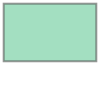

In [15]:
aoi_shape = shape(geojson_geometry)
aoi_shape

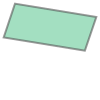

In [16]:
item_shape = shape(item_geom)
item_shape

Opomba: Če je aoi_shape v celoti vključen v prizor, bo clipped_shape identičen aoi_shape.

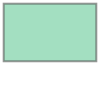

In [17]:
clipped_shape = item_shape.intersection(aoi_shape)
clipped_shape

Upoštevajte, da je izrezano območje lahko precej manjše od celotne scene. To pomeni, da se lahko z branjem COG zmanjša stroške, ki bi nastali pri prenosu celotne scene.

In [18]:
print(f'Površina celotnega posnetka: {item_shape.area:.4f}')
print(f'Površina izrezanega območja: {clipped_shape.area:.4f}')

Površina celotnega posnetka: 0.0813
Površina izrezanega območja: 0.0013


In [19]:
# Preveri ali obstaja mapa rezultati, če ne, jo ustvari
if not os.path.exists('rezultati'):
    os.makedirs('rezultati')

In [20]:
# Prenesi izrezano območje kot COG
with rasterio.open(download_link) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    aoi_transformed = Polygon(
        [transformer.transform(*coords) for coords in mapping(clipped_shape)["coordinates"][0]]
    )

    window = from_bounds(*aoi_transformed.bounds, transform=src.transform)
    
    clipped_data = src.read(window=window)
    
    # Prilagodite transformacijo za izrezano območje
    clipped_transform = src.window_transform(window)
    
    # Shranite izrezano območje kot nov COG
    out_meta = src.meta.copy()
    out_meta.update({
        "height": clipped_data.shape[1],
        "width": clipped_data.shape[2],
        "transform": clipped_transform,
        "driver": "COG"
    })
    
    id_file_name = f"./rezultati/{item_id}_cl.tif"
    with rasterio.open(id_file_name, 'w', **out_meta) as dst:
        dst.write(clipped_data)

Izrezano območje lahko prikažemo, recimo v QGISu.

![Kranj AOI](slike/qgis_planet_kranj_cl.jpg)

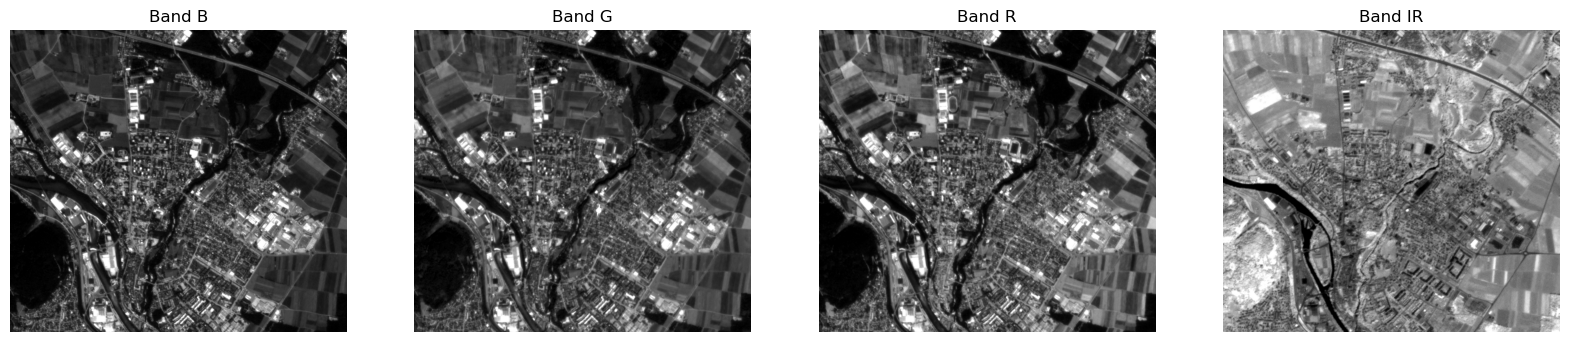

In [21]:
# Preberi izrezano območje in prikaži kanale R, G, B, IR
with rasterio.open(id_file_name) as src:
    data = src.read()
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    band_names = ['B', 'G', 'R', 'IR']
    for i in range(4):
        # Raztegni na 1% - 99% vrednosti za boljši prikaz
        p1, p99 = np.percentile(data[i], (1, 99))
        data[i] = np.clip(data[i], p1, p99)
        axes[i].imshow(data[i], cmap='gray')
        axes[i].set_title(f'Band {band_names[i]}')
        axes[i].axis('off')
    plt.show()


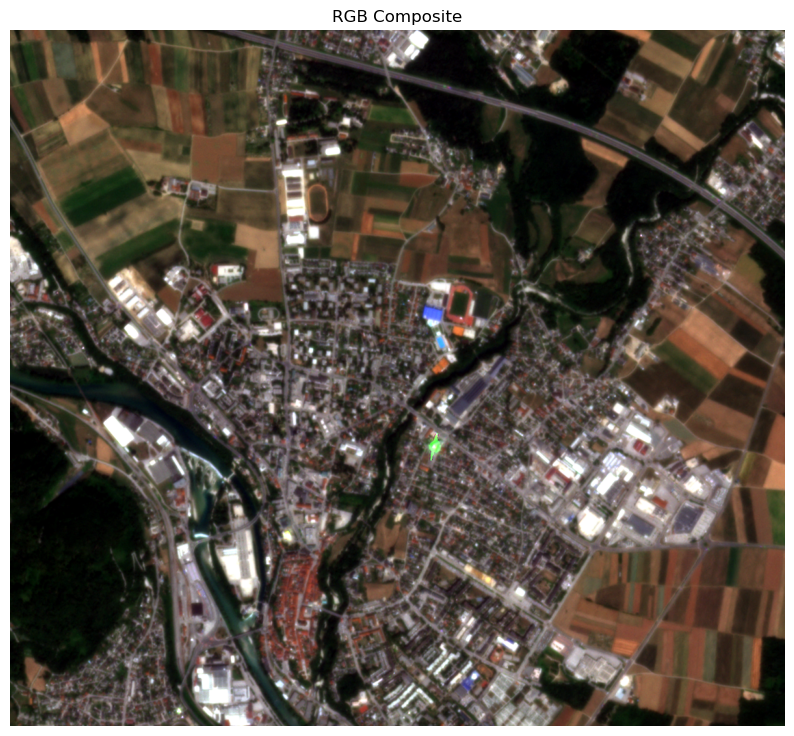

In [22]:
# Prikaži kombinacijo RGB kanalov
with rasterio.open(id_file_name) as src:
    data = src.read().astype(float)
    # Raztegni na 1% - 99% vrednosti za boljši prikaz in 0-255
    bands = []
    for i in [2, 1, 0]:  # R, G, B
        p1, p99 = np.percentile(data[i], (1, 99))
        band = np.clip(data[i], p1, p99)
        band = ((band - p1) / (p99 - p1) * 255).astype(np.uint8)
        bands.append(band)
    rgb_image = np.dstack(bands)
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)
    plt.title('RGB Composite')
    plt.axis('off')
    plt.show()

Ker smo izkoristili branje v oknu z majhnim AOI, bi morala biti zgornja celica veliko hitrejša kot renderiranje celotne scene.

## Iračunanje NDVI znotraj AOI

Ker smo izkoristili analyticno sliko, se ne omejimo le na vizualni prikaz v RGB. Poglejmo nekaj operacij z rdečo in NIR pasom, da prikažemo pseudo-NDVI. Za pravi [NDVI](https://developers.planet.com/docs/planetschool/calculate-an-ndvi-in-python/) bi morali poiskati specifične metadata koeficiente za vsak pas.

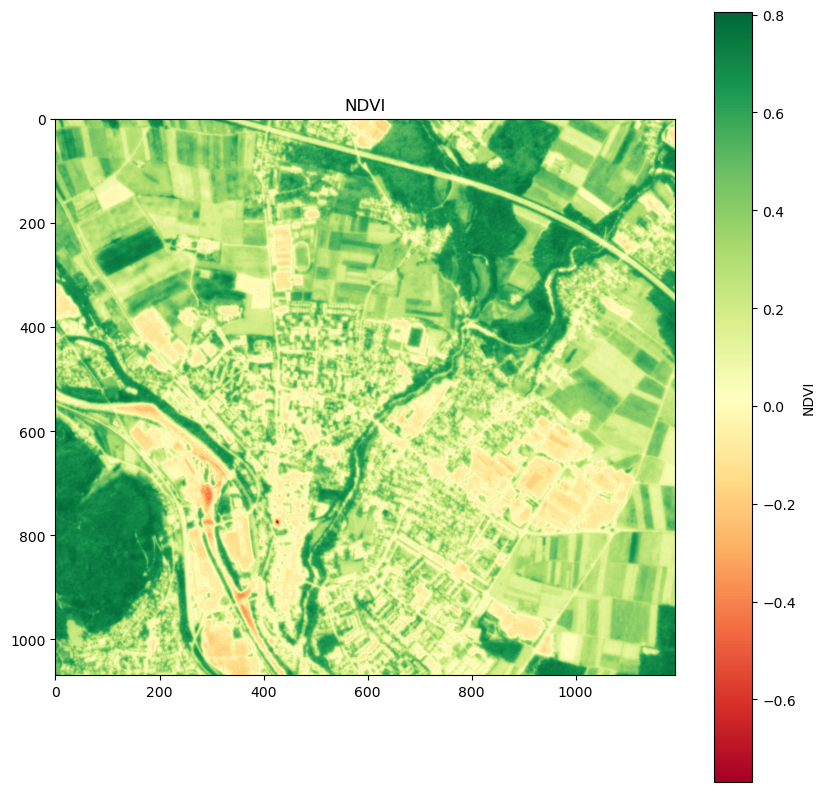

In [23]:
# Copmute and display NDVI
with rasterio.open(id_file_name) as src:
    data = src.read().astype(float)
    # Rdeči pas je indeks 2, NIR pas je indeks 3
    red = data[2]
    nir = data[3]
    
    # Izračun NDVI (brez korekcije za reflektance)
    ndvi = (nir - red) / (nir + red + 1e-6)  # Dodaj majhno vrednost za izogibanje deljenju z ničlo
    
    plt.figure(figsize=(10, 10))
    plt.imshow(ndvi, cmap='RdYlGn')
    plt.colorbar(label='NDVI')
    plt.title('NDVI')
    plt.show()